## How does investment participation differ between young people in the UK and USA?

This project explores the differences in investment participation among the young people between the UK and USA. The metrics used include:  direct investments, non-retirement investment participation, ISA participation and cryptocurrency involvement. Where possible, data from 2024 and similar age groups are used. However when this is unavailable, the closest suitable metric is used. Metrics that are not sufficiently comparable have not been forced into a quantitative comparison.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("youth_investment_data.csv")

## Direct and market investment participation

In [2]:
uk_18to24 = df[
    (df["metric"] == "Direct shares/equities") &
    (df["age_group"] == "18-24")
    ]

uk_25to34 = df[
    (df["metric"] == "Direct shares/equities") &
    (df["age_group"] == "25-34")
    ]

usa = df[df["metric"] == "Non-retirement market investment participation"]


uk_value18_24 = uk_18to24["value"].iloc[0]
usa_value = usa["value"].iloc[0]
uk_value25_34 = uk_25to34["value"].iloc[0]


difference = ((usa_value - uk_value18_24)/uk_value18_24)*100


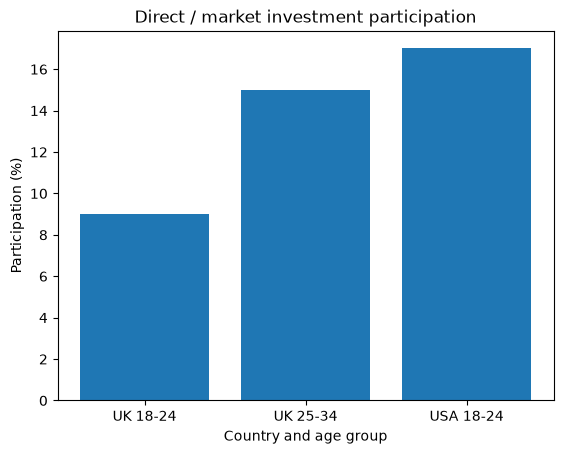

In [3]:
categories = ["UK 18-24", "UK 25-34", "USA 18-24"]
values = [uk_value18_24, uk_value25_34, usa_value]

plt.bar(categories, values)
plt.title("Direct / market investment participation")
plt.xlabel("Country and age group")
plt.ylabel("Participation (%)")

plt.show()

In [4]:
print("Proportion of 18-24 year olds in the UK holding direct shares/equities is", uk_value18_24, "%")
print("Proportion of 18-24 year olds in the USA participating in non-retirement market investment is", usa_value, "%")
print("Proportion of 25-34 year olds in the UK holding direct shares/equities is", uk_value25_34, "%")
print(f"US participation is {difference:.1f}% higher than the UK")

percentage_point_gap = usa_value - uk_value18_24

print(f"The US participation rate is {percentage_point_gap} percentage points higher than the UK rate.")

Proportion of 18-24 year olds in the UK holding direct shares/equities is 9 %
Proportion of 18-24 year olds in the USA participating in non-retirement market investment is 17 %
Proportion of 25-34 year olds in the UK holding direct shares/equities is 15 %
US participation is 88.9% higher than the UK
The US participation rate is 8 percentage points higher than the UK rate.


The data shows significant difference in direct and market investment participation among young adults between the two countries. Among 18–24-year-olds, the US participation rate is 17%, compared with 9% direct share ownership in the UK. This represents an 8 percentage-point gap, with the US measure approximately 88.9% higher relative to the UK rate.

However, this measure of difference should be interpreted with caution. The US measure of non-retirement market investment participation is broader. This includes bonds, ETFs and mutual funds. The UK measure of direct ownership involves ownership of company shares/equities while excluding holdings through ISAs and pensions Hence, part of the observed difference may result from the broader US definition, thus the analysis cannot determine that young Americans are 88.9% more likely to own shares.

Within the UK, direct share ownership also rises from 9% among 18–24-year-olds to 15% among 25–34-year-olds. This suggests that participation increases considerably across these two age groups.

## UK Stocks and Shares ISA Participation

In [5]:
ISA_18to24 = df[
    (df["metric"] == "Stocks & Shares ISA participation") &
    (df["age_group"] == "18-24")
    ]

ISA_25to34 = df[
    (df["metric"] == "Stocks & Shares ISA participation") &
    (df["age_group"] == "25-34")
    ]

UK_18to24 = ISA_18to24["value"].iloc[0]
UK_25to34 = ISA_25to34["value"].iloc[0]


ISA_difference = ((UK_25to34 - UK_18to24)/UK_18to24)*100

ISA_percentage_point_gap = UK_25to34 - UK_18to24



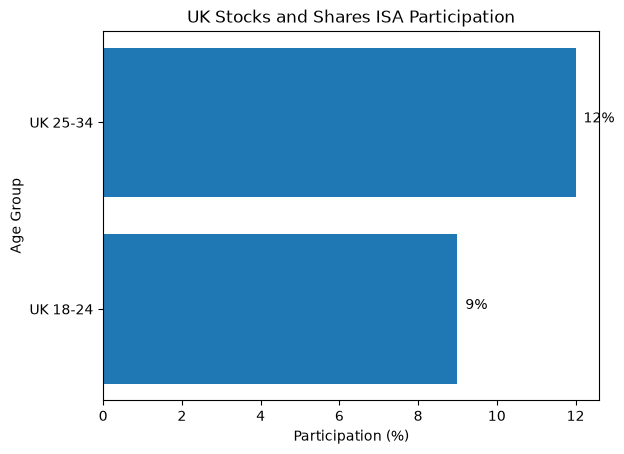

In [6]:
categories = ["UK 18-24", "UK 25-34"]
values = [UK_18to24, UK_25to34]

plt.title("UK Stocks and Shares ISA Participation")
plt.ylabel("Age Group")
plt.xlabel("Participation (%)")

bars = plt.barh(categories, values)

for bar in bars:
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width()}%",
        
    )

plt.show()

In [7]:
print(f"The difference in ISA participation between 18-24 and 25-34 year olds is {ISA_difference:.1f}%")
print(f"The percentage point difference is {ISA_percentage_point_gap}")

The difference in ISA participation between 18-24 and 25-34 year olds is 33.3%
The percentage point difference is 3


Stocks and Shares ISA participation increases from 9% among UK 18–24-year-olds to 12% among 25–34-year-olds. This represents an increase of 3 percentage points, or 33.3% relative to the participation rate of the younger group. This indicates that Stocks and Shares ISA participation is higher among the older age group.

The age difference is smaller than for direct share ownership. Direct share ownership therefore rises by 6 percentage points compared with a 3 percentage-point increase in Stocks and Shares ISA participation. This suggests that the relationship between age and investment participation differs depending on the form of investment being measured.

A direct US comparison was considered but ultimately excluded. A taxable brokerage account is the closest US equivalent to a UK Stocks and Shares ISA but no suitable comparable statistic for youth brokerage account participation could be identified.

## Cryptocurrencies

In [8]:
Crypto_18to24 = df[
    (df["metric"] == "Cryptoasset ownership/investment") &
    (df["age_group"] == "18-24")
    ]

Crypto_25to34 = df[
    (df["metric"] == "Cryptoasset ownership/investment") &
    (df["age_group"] == "25-34")
    ]

USA_crypto = df[
    df["metric"] == "Crypto bought or held as an investment"
]

UK_crypto_18to24 = Crypto_18to24["value"].iloc[0]
UK_crypto_25to34 = Crypto_25to34["value"].iloc[0]
USA_crypto_value = USA_crypto["value"].iloc[0]

crypto_gap = USA_crypto_value - UK_crypto_18to24
UK_crypto_gap = UK_crypto_25to34 - UK_crypto_18to24



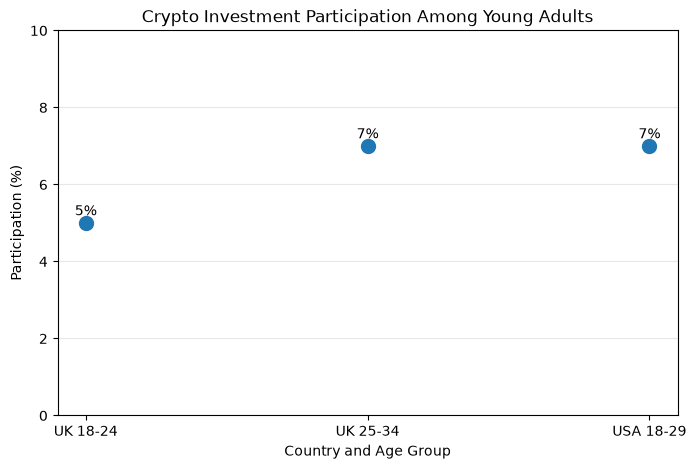

In [9]:
categories = ["UK 18-24", "UK 25-34", "USA 18-29"]
values = [UK_crypto_18to24, UK_crypto_25to34, USA_crypto_value]

plt.figure(figsize=(8, 5))

plt.scatter(categories, values, s=100)

for category, value in zip(categories, values):
    plt.text(category, value + 0.2, f"{value}%", ha="center")

plt.title("Crypto Investment Participation Among Young Adults")
plt.xlabel("Country and Age Group")
plt.ylabel("Participation (%)")

plt.ylim(0, 10)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [10]:
print(f"The crypto gap between the two countries is {crypto_gap} percentage points ")
print(f"UK 25-34 vs UK 18-24 gap: {UK_crypto_gap} percentage points")

The crypto gap between the two countries is 2 percentage points 
UK 25-34 vs UK 18-24 gap: 2 percentage points


Crypto investment participation is relatively low across all three observations. In the UK, participation increases from 5% among 18–24-year-olds to 7% among 25–34-year-olds, representing a 2 percentage-point difference. The US figure for 18–29-year-olds is also 7%, only 2 percentage points above the UK 18–24 figure.

This contrasts with the larger difference observed in the earlier comparison of non-retirement market participation, where the US figure was 17% compared with 9% direct share ownership among UK 18–24-year-olds. Although those measures are not perfectly equivalent, the crypto data suggests that the apparent UK-US participation gap is not consistent across all forms of investment.

However, the crypto comparison should be interpreted cautiously. The UK observations are from 2024 and use the age groups 18–24 and 25–34, whereas the US observation is from 2023 and covers 18–29-year-olds. The figures therefore provide an approximate indication of differences in crypto participation rather than a perfect cross-country comparison. 

## Conclusion

Overall, investment participation among young adults differ between the UK and US. However, the size of the difference depends on the type of investment. 

The largest observed difference was in the market participation comparison, where 17% of US 18–24-year-olds held non-retirement market investments compared with 9% of UK 18–24-year-olds holding direct shares/equities. However, the broader definition of the US measure means that this should not be interpreted as a perfectly like-for-like comparison.

Within the UK, both direct share ownership and Stocks and Shares ISA participation were higher among 25–34-year-olds than among 18–24-year-olds, suggesting that investment participation is associated with age within the available data. Crypto showed an interesting pattern. The measured difference between young adults in the UK and US was much smaller, with UK 18–24 participation at 5% compared with 7% among US 18–29-year-olds.

Ultimately, the data suggests there is no single UK and US youth investment gap. The apparent difference varies depending on the investment product being examined and the way participation is measured.

## Bibliography

1. Financial Conduct Authority (2025) Financial Lives 2024 survey: Consumer       investments – selected findings. London: Financial Conduct Authority. 

2. Board of Governors of the Federal Reserve System (2025) Economic Well-Being    of U.S. Households in 2024. Washington, DC: Board of Governors of the          Federal Reserve System.

3. Board of Governors of the Federal Reserve System (2024) Economic Well-Being    of U.S. Households in 2023. Washington, DC: Board of Governors of the          Federal Reserve System.
